## EIT Parser Validation

Validates that `DragerEitParser` reads `.eit` files correctly and that the
calibration pipeline produces physically plausible transimpedance values.

Calibration pipeline (empirical constants from EIDORS, A. Adler 2016 — hardcoded, not in the header):
- `vv = FT_A * trans_A - FT_B * trans_B`  → calibrated transimpedance [Ω]
- `I_real = injection_current / FC_CURRENT` → actual injected current [A]
- `V_diff = (voltage_A - voltage_B) / FV_VOLTAGE` → differential voltage [V]

Cross-validation against the corresponding `.bin` file (vendor-reconstructed 32×32 images).

The goal of this notebook is far from providing a physically valid reconstruction pipeline.
The primary intent is simply to demonstrate the validity of `DragerEitParser`, the data
calibrated with the EIDORS constants, and to show the bridge toward Python EIT reconstruction
libraries such as pyEIT for those who wish to work with raw transimpedance signals.

In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from fasteit.parsers.draeger.eit.eit_parser import DragerEitParser
from fasteit.parsers.draeger.bin.bin_parser import DragerBinParser

In [12]:
EIT_FILE = Path("../src/fasteit/test_files/patient01.eit")
BIN_FILE = Path("../src/fasteit/test_files/patient01.bin")

eit = DragerEitParser().parse(EIT_FILE)
bin_ = DragerBinParser().parse(BIN_FILE)

## 1. Parser output structure

In [13]:
from fasteit.parsers.draeger.eit.eit_utils import FT_A, FT_B, FC_CURRENT, FV_VOLTAGE

print("=== .eit parser output ===")
print(f"measurements (vv) shape : {eit.measurements.shape}")
print(f"fs                      : {eit.fs} Hz")
print(f"n_frames                : {eit.metadata['n_frames']}")
print(f"n_electrodes            : {eit.metadata['n_electrodes']}")
print(f"n_measurements          : {eit.metadata['n_measurements']}")
print(f"detected_spec           : {eit.metadata['detected_spec']}")
print(f"date / time             : {eit.metadata.get('date')} {eit.metadata.get('time')}")
print(f"frequency               : {eit.metadata.get('frequency_khz')} kHz")
print(f"amplitude               : {eit.metadata.get('amplitude_ua')} µA")
print()
print("calibration constants (EIDORS hardcoded, A. Adler 2016):")
print(f"  FT_A={FT_A}, FT_B={FT_B}, FC_CURRENT={FC_CURRENT}, FV_VOLTAGE={FV_VOLTAGE}")
print()
print("aux_signals keys:", list(eit.aux_signals.keys()))

=== .eit parser output ===
measurements (vv) shape : (11500, 208)
fs                      : 50.0 Hz
n_frames                : 11500
n_electrodes            : 16
n_measurements          : 208
detected_spec           : Draeger_EIT_v51
date / time             : 04.01.2024 18:10:54.015
frequency               : 101.501 kHz
amplitude               : 9100.0 µA

calibration constants (EIDORS hardcoded, A. Adler 2016):
  FT_A=0.00098242, FT_B=0.00019607, FC_CURRENT=194326.3536, FV_VOLTAGE=0.11771

aux_signals keys: ['timestamp', 'trans_A', 'trans_B', 'injection_current', 'I_real', 'voltage_A', 'voltage_B', 'V_diff', 'frame_counter', 'medibus']


## 2. Sanity check: vv is non-zero and NaN-free

In [14]:
vv = eit.measurements

print(f"NaN count : {np.isnan(vv).sum()}")
print(f"Zero rows : {(vv == 0).all(axis=1).sum()}")
print(f"min / max : {vv.min():.4f} / {vv.max():.4f}")
print(f"mean      : {vv.mean():.4f}")

NaN count : 0
Zero rows : 0
min / max : -0.0000 / 0.1597
mean      : 0.0125


## 3. Timestamps are monotonically increasing

In [15]:
ts = eit.aux_signals["timestamp"]
print(f"Timestamp range : {ts.min():.6f} – {ts.max():.6f} (fraction of day)")
print(f"Monotonically increasing: {bool(np.all(np.diff(ts) >= 0))}")
print(f"Duration approx : {(ts.max() - ts.min()) * 24 * 60:.1f} min")

Timestamp range : 0.757570 – 0.760232 (fraction of day)
Monotonically increasing: True
Duration approx : 3.8 min


## 4. Calibrated transimpedance waveform — measurement 0, first 500 frames

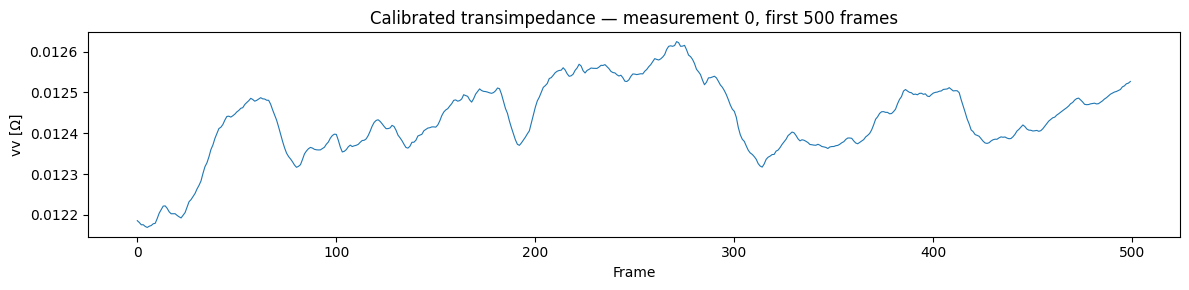

In [16]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(vv[:500, 0], lw=0.8)
ax.set_xlabel("Frame")
ax.set_ylabel("vv [Ω]")
ax.set_title("Calibrated transimpedance — measurement 0, first 500 frames")
plt.tight_layout()
plt.show()

## 5. Frame count comparison: .eit vs .bin

In [17]:
print(f".eit n_frames : {eit.metadata['n_frames']}")
print(f".bin n_frames : {bin_.n_frames}")
print(f".eit fs       : {eit.fs} Hz")
print(f".bin fs       : {bin_.fs} Hz")

delta = abs(eit.metadata['n_frames'] - bin_.n_frames)

.eit n_frames : 11500
.bin n_frames : 11500
.eit fs       : 50.0 Hz
.bin fs       : 50.0 Hz


## 6. GREIT reconstruction — transimpedances to 32×32 image

`reconstruct_greit()` converts `vv` (N_frames, 208) to 32×32 images using the
GREIT algorithm (Adler et al., *Physiol. Meas.* 2009).
Reconstruction is differential: each pixel shows Δσ relative to a reference frame.
First 50 frames used as baseline (stable period before the respiratory cycle).

In [ ]:
from fasteit.parsers.draeger.eit.eit_pyeit_bridge import reconstruct_greit

# Use first 50 frames as baseline (stable reference period)
images = reconstruct_greit(vv, ref_frame=(0, 50))

print(f"Input  : vv.shape = {vv.shape}")
print(f"Output : images.shape = {images.shape}")
print(f"NaN pixels per frame  : {np.isnan(images[0]).sum()} / {images[0].size} (outside electrode circle)")

## 6b. Sign correction

The GREIT algorithm outputs conductivity change (Δσ): when air enters the lungs,
conductivity decreases → signal goes down.
Dräger uses the **impedance** convention: air enters → impedance rises → signal goes up.

Negating the GREIT output brings it into the Dräger convention.
The correction is applied inside `reconstruct_greit()` so callers never need to
handle it manually.

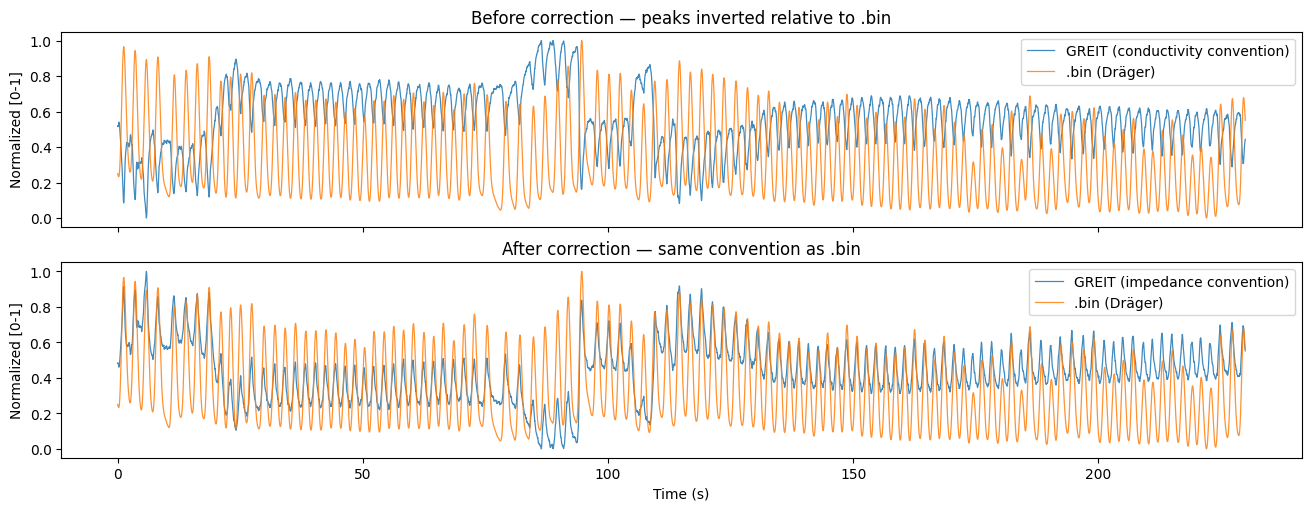

In [19]:
# Global EIT signal: sum of all pixels per frame
global_greit = np.nansum(images, axis=(1, 2))
time = np.arange(len(global_greit)) / eit.fs

global_bin = bin_.global_signal
time_bin = np.arange(len(global_bin)) / bin_.fs

def norm01(x):
    return (x - x.min()) / (x.max() - x.min())

fig, axes = plt.subplots(2, 1, figsize=(13, 5), layout="constrained", sharex=True)

# Before correction: peaks were inverted relative to .bin
axes[0].plot(time, norm01(-global_greit), lw=0.9, color="C0", label="GREIT (conductivity convention)", alpha=0.85)
axes[0].plot(time_bin, norm01(global_bin), lw=0.9, color="C1", label=".bin (Dräger)", alpha=0.85)
axes[0].set_ylabel("Normalized [0-1]")
axes[0].set_title("Before correction — peaks inverted relative to .bin")
axes[0].legend()

# After correction: reconstruct_greit() negates internally
axes[1].plot(time, norm01(global_greit), lw=0.9, color="C0", label="GREIT (impedance convention)", alpha=0.85)
axes[1].plot(time_bin, norm01(global_bin), lw=0.9, color="C1", label=".bin (Dräger)", alpha=0.85)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Normalized [0-1]")
axes[1].set_title("After correction — same convention as .bin")
axes[1].legend()

plt.show()

## 7. Image sequence over one respiratory cycle

4 seconds of consecutive frames (~200 frames at 50 Hz) to observe how the
reconstructed image evolves through inspiration and expiration.
The high-intensity region on the left of the raw image is likely the cardiac signal.
The image does not appear correctly oriented.

From the documentation, pyEIT places electrode 0 at 3 o'clock, while the Dräger
PulmoVista 500 belt places electrode 1 on the anterior chest wall. The images are
likely not correctly oriented without the rotation and flip transforms.

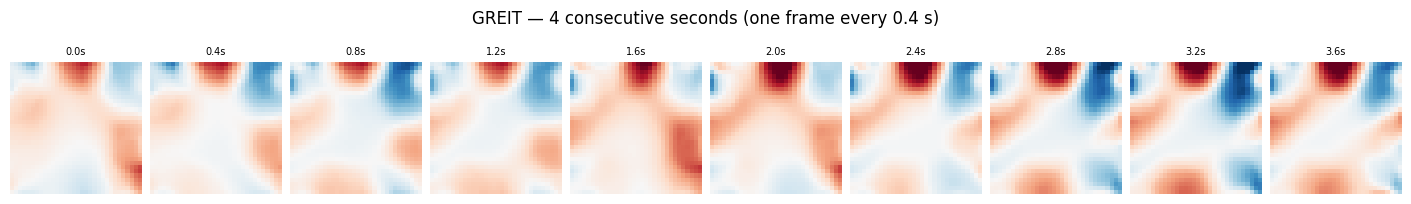

In [20]:
# 4 seconds of consecutive frames around the middle of the recording
t_start = len(images) // 2          # start at midpoint
n_sec = 4                            # seconds to show
n_frames_show = int(n_sec * eit.fs)  # ~200 frames
frame_idx = range(t_start, t_start + n_frames_show)

# One frame every 0.4 s
step = int(0.4 * eit.fs)
selected = list(frame_idx)[::step]

ncols = len(selected)
fig, axes = plt.subplots(1, ncols, figsize=(ncols * 1.4, 2.2), layout="constrained")
vmax = np.nanpercentile(np.abs(images[list(frame_idx)]), 99)

for ax, idx in zip(axes, selected):
    ax.imshow(images[idx], cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="lower")
    ax.set_title(f"{(idx - t_start)/eit.fs:.1f}s", fontsize=7)
    ax.axis("off")

fig.suptitle("GREIT — 4 consecutive seconds (one frame every 0.4 s)")
plt.show()

## 9. Frame alignment: .eit vs .bin

The PulmoVista 500 records **only the `.eit` file** (raw transimpedances).
The `.bin` is generated afterward by Dräger's software, which applies its
Newton-Raphson FEM reconstruction to each `.eit` frame in sequence.

This means frame *k* in `.bin` is the reconstruction of frame *k* in `.eit`
**by construction**, a temporal offset is architecturally impossible.

A lag of 0 also validates that the paired dataset for the data-driven
reconstruction model (ML branch) is perfectly aligned with zero noise from
frame misalignment.

## Summary

**Conclusion**: the `.eit` → `RawImpedanceData` → pyEIT bridge is functional for those
who wish to work with EIT reconstruction algorithms.
`DragerEitParser` correctly extracts 208 calibrated transimpedances per frame,
timestamps, and auxiliary signals. GREIT reconstruction is available as an optional
utility (`fasteit[pyeit]`).

The spatial quality of GREIT images with a generic circular mesh does not match
the vendor-reconstructed `.bin` (Dräger uses a proprietary algorithm and mesh).